# Sistema de Monitoreo Ambiental Inteligente para Invernadero
## Prototipo de Machine Learning

**Tecnologías Emergentes I — Caso de estudio: invernadero del Colegio Club de Leones (La Paz)**

Este cuaderno implementa el núcleo de Machine Learning del sistema:

1. Genera un **conjunto de datos simulado** de las variables ambientales del invernadero (temperatura, humedad y luminosidad).
2. Entrena modelos de **predicción de temperatura** (Random Forest y Gradient Boosting).
3. Entrena un modelo de **detección de anomalías** (Isolation Forest).

> **Nota:** ante la imposibilidad de acceder a mediciones físicas del invernadero, se utiliza un dataset simulado que reproduce el comportamiento ambiental característico de la ciudad de La Paz (ciclos día-noche, heladas nocturnas propias de la altitud y fallos esporádicos de sensor).



## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import precision_score, recall_score, f1_score

# Semilla para resultados reproducibles
rng = np.random.default_rng(42)

## 2. Generación del conjunto de datos simulado

Se generan **60 días** de lecturas **horarias** (1 440 registros) de temperatura, humedad relativa y luminosidad. El modelo reproduce:
- el **ciclo diario** (cálido al mediodía, frío de noche),
- **heladas nocturnas** en aproximadamente el 15 % de las noches,
- y un **2 % de lecturas anómalas** que simulan fallos de sensor (picos imposibles).

In [2]:
N_DAYS = 60
H = N_DAYS * 24
ts = pd.date_range("2026-03-01", periods=H, freq="h")
hod = ts.hour.values

# Temperatura: media diaria (caminata aleatoria) + ciclo diurno + ruido
daily_mean = np.clip(14 + np.cumsum(rng.normal(0, 0.3, N_DAYS)), 10, 18)
daily_mean_h = np.repeat(daily_mean, 24)[:H]
temp = daily_mean_h + 8*np.cos(2*np.pi*(hod-14)/24) + rng.normal(0, 1.0, H)

# Heladas nocturnas (~15% de las noches)
frost = rng.random(N_DAYS) < 0.15
for d in np.where(frost)[0]:
    idx = np.arange(d*24, min((d+1)*24, H))
    night = idx[(hod[idx] <= 6) | (hod[idx] >= 22)]
    temp[night] -= rng.uniform(6, 10)

# Humedad: anti-correlacionada con la temperatura
hum = np.clip(92 - 1.6*temp + rng.normal(0, 4, H), 25, 96)

# Luminosidad: solo de día, forma de campana con factor de nubosidad
lum = np.zeros(H)
day = (hod >= 6) & (hod <= 18)
cloud = np.repeat(rng.uniform(0.6, 1.0, N_DAYS), 24)[:H]
lum[day] = np.clip(1050*np.sin(np.pi*(hod[day]-6)/12)*cloud[day] + rng.normal(0, 40, day.sum()), 0, None)

# Señal limpia (para el modelo de predicción)
temp_c, hum_c, lum_c = temp.copy(), hum.copy(), lum.copy()

# Dataset con anomalías inyectadas (~2%) y su etiqueta
df = pd.DataFrame({"fecha_hora": ts, "temperatura": temp.round(2),
                   "humedad": hum.round(1), "luminosidad": lum.round(0), "is_anomaly": 0})
n_anom = int(0.02*H)
anom_idx = rng.choice(H, n_anom, replace=False)
for i in anom_idx:
    k = rng.integers(0, 3)
    if k == 0:   df.loc[i, "temperatura"] = round(float(rng.uniform(45, 60)), 2)
    elif k == 1: df.loc[i, "humedad"] = float(rng.choice([0.0, 100.0]))
    else:        df.loc[i, "luminosidad"] = round(float(rng.uniform(3000, 6000)))
    df.loc[i, "is_anomaly"] = 1

df.to_csv("dataset_invernadero_simulado.csv", index=False)
print(f"Dataset generado: {H} registros  |  {n_anom} anomalías inyectadas  |  {int(frost.sum())} noches con helada")
df.head()

Dataset generado: 1440 registros  |  28 anomalías inyectadas  |  5 noches con helada


,fecha_hora,temperatura,humedad,luminosidad,is_anomaly
0,2026-03-01 00:00:00,5.48,80.7,0.0,0
1,2026-03-01 01:00:00,6.03,77.7,0.0,0
2,2026-03-01 02:00:00,6.25,82.6,0.0,0
3,2026-03-01 03:00:00,6.95,83.8,0.0,0
4,2026-03-01 04:00:00,7.87,73.1,0.0,0


## 3. Exploración y visualización del dataset

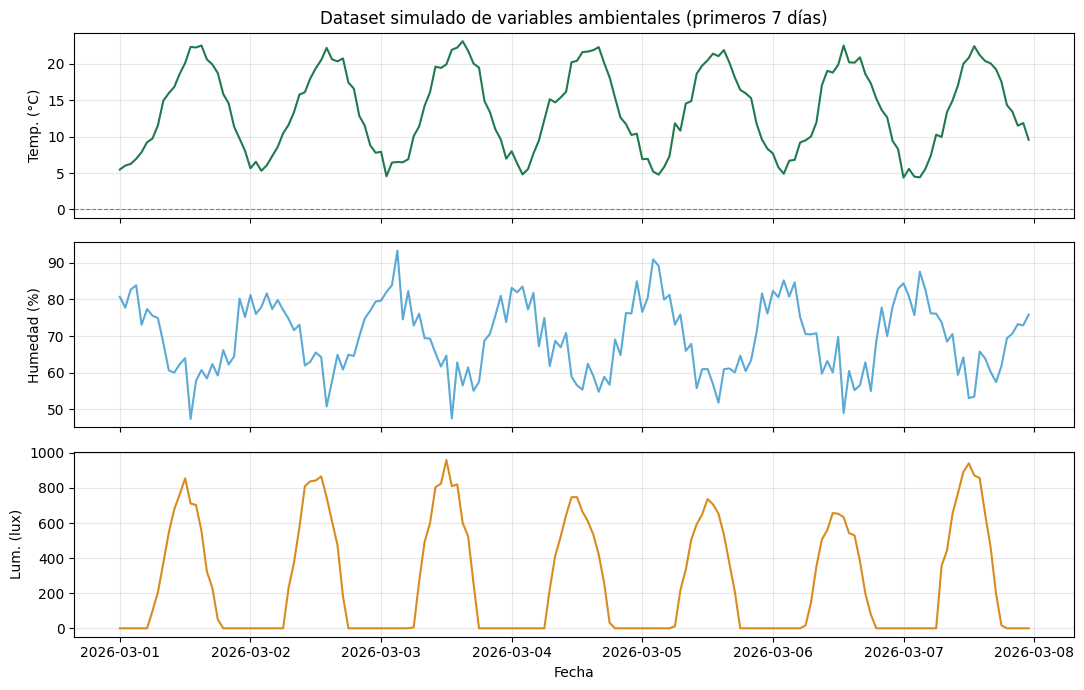

,temperatura,humedad,luminosidad
count,1440.000000,1440.000000,1440.000000
mean,14.301000,69.250208,283.448611
std,7.023218,11.664402,420.954739
min,-5.660000,0.000000,0.000000
25%,8.657500,60.675000,0.000000
50%,14.480000,69.000000,2.500000
75%,19.872500,78.100000,572.500000
max,59.940000,100.000000,5939.000000


In [3]:
w = 7 * 24  # primeros 7 días
fig, ax = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
ax[0].plot(ts[:w], temp_c[:w], color="#1f7a4d"); ax[0].set_ylabel("Temp. (°C)")
ax[0].axhline(0, color="#d65a5a", ls="--", lw=0.8); ax[0].grid(alpha=0.3)
ax[0].set_title("Dataset simulado de variables ambientales (primeros 7 días)")
ax[1].plot(ts[:w], hum_c[:w], color="#5aa9d6"); ax[1].set_ylabel("Humedad (%)"); ax[1].grid(alpha=0.3)
ax[2].plot(ts[:w], lum_c[:w], color="#d98b1f"); ax[2].set_ylabel("Lum. (lux)"); ax[2].grid(alpha=0.3)
ax[2].set_xlabel("Fecha")
plt.tight_layout(); plt.show()

df[["temperatura", "humedad", "luminosidad"]].describe()

## 4. Modelo de predicción de temperatura

Se predice la **temperatura de la hora siguiente** a partir de la hora del día, las lecturas actuales y los valores recientes. Se comparan dos modelos de regresión: **Random Forest** y **Gradient Boosting**.

Métricas: **MAE** (error absoluto medio), **RMSE** (raíz del error cuadrático medio) y **R²** (coeficiente de determinación).

In [4]:
hour_sin = np.sin(2*np.pi*hod/24)
hour_cos = np.cos(2*np.pi*hod/24)

# Variables predictoras y objetivo (temperatura de la hora siguiente)
X = np.column_stack([hour_sin, hour_cos, temp_c, hum_c, lum_c, np.roll(temp_c, 1)])[1:-1]
y = temp_c[2:]

# División temporal: 80% entrenamiento, 20% prueba
split = int(0.8 * len(X))
Xtr, Xte, ytr, yte = X[:split], X[split:], y[:split], y[split:]

rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(Xtr, ytr)
gb = GradientBoostingRegressor(n_estimators=200, random_state=42).fit(Xtr, ytr)

print("Resultados de la predicción de temperatura:\n")
for name, m in [("Random Forest", rf), ("Gradient Boosting", gb)]:
    p = m.predict(Xte)
    print(f"{name:18s}  MAE = {mean_absolute_error(yte, p):.2f} °C    "
          f"RMSE = {np.sqrt(mean_squared_error(yte, p)):.2f} °C    "
          f"R² = {r2_score(yte, p):.3f}")

Resultados de la predicción de temperatura:

Random Forest       MAE = 1.20 °C    RMSE = 1.48 °C    R² = 0.941
Gradient Boosting   MAE = 1.17 °C    RMSE = 1.46 °C    R² = 0.942


### Comparación de valores reales vs. predichos

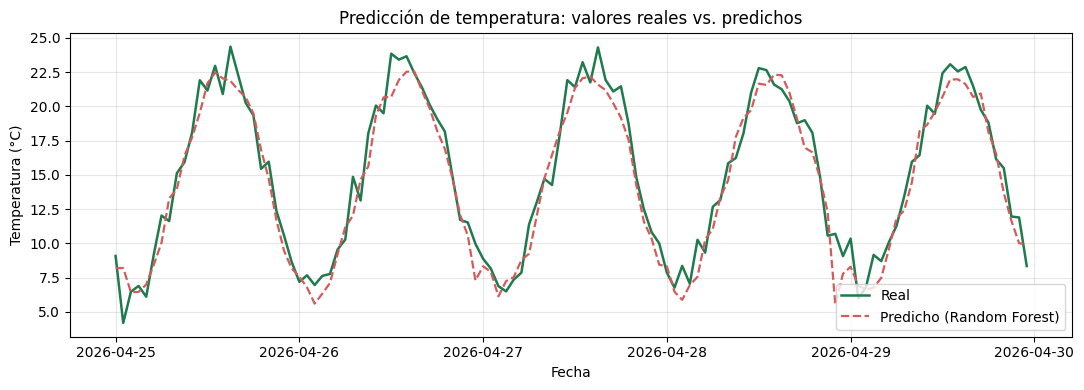

In [5]:
p_rf = rf.predict(Xte)
ts_te = ts[2:][split:]
m = min(120, len(ts_te))  # últimas ~5 días del conjunto de prueba

plt.figure(figsize=(11, 4))
plt.plot(ts_te[-m:], yte[-m:], color="#1f7a4d", label="Real", lw=1.8)
plt.plot(ts_te[-m:], p_rf[-m:], color="#d65a5a", ls="--", label="Predicho (Random Forest)", lw=1.6)
plt.title("Predicción de temperatura: valores reales vs. predichos")
plt.xlabel("Fecha"); plt.ylabel("Temperatura (°C)"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Detección de anomalías

Se utiliza **Isolation Forest** (aprendizaje no supervisado) para identificar lecturas inconsistentes sobre las tres variables. Como el dataset tiene etiquetadas las anomalías inyectadas, se evalúa con **precisión, recall y F1**.

In [6]:
Xa = np.column_stack([df["temperatura"], df["humedad"], df["luminosidad"], hour_sin, hour_cos])
iso = IsolationForest(contamination=0.02, random_state=42).fit(Xa)
pred_anom = (iso.predict(Xa) == -1).astype(int)
yt = df["is_anomaly"].values

print("Resultados de la detección de anomalías:\n")
print(f"Anomalías detectadas: {int(pred_anom.sum())}")
print(f"Precisión = {precision_score(yt, pred_anom):.2f}    "
      f"Recall = {recall_score(yt, pred_anom):.2f}    "
      f"F1 = {f1_score(yt, pred_anom):.2f}")

Resultados de la detección de anomalías:

Anomalías detectadas: 29
Precisión = 0.69    Recall = 0.71    F1 = 0.70


### Visualización de las anomalías detectadas

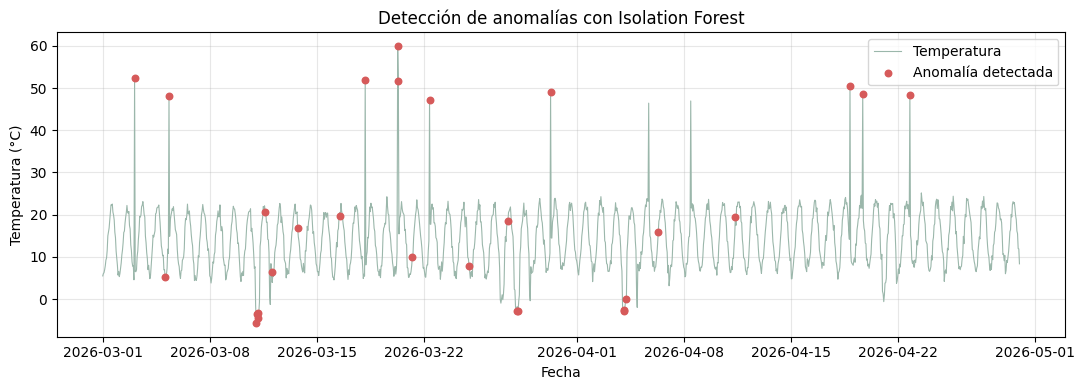

In [7]:
det = pred_anom == 1
plt.figure(figsize=(11, 4))
plt.plot(ts, df["temperatura"], color="#9bb7ab", lw=0.8, label="Temperatura")
plt.scatter(ts[det], df["temperatura"][det], color="#d65a5a", s=22, zorder=5, label="Anomalía detectada")
plt.title("Detección de anomalías con Isolation Forest")
plt.xlabel("Fecha"); plt.ylabel("Temperatura (°C)"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Conclusiones del prototipo

- Los modelos de **predicción de temperatura** (Random Forest y Gradient Boosting) alcanzan un **R² ≈ 0,94** y un error medio de **≈ 1,2 °C**, lo que permite anticipar condiciones críticas como las heladas.
- El modelo de **detección de anomalías** (Isolation Forest) identifica las lecturas inconsistentes con un **F1 ≈ 0,70**, marcando de forma efectiva los fallos de sensor.

Estos resultados validan la viabilidad técnica del sistema. En una implementación real, los datos simulados se reemplazarían por mediciones de sensores físicos, reentrenando los modelos con dichos datos.